# DragonFlow — 中证2000成分股画像分析

**从夯到拉锐评2026年1至5月热点龙头股**

本 Notebook 从大盘全景、风险收益、量价异动、聚类画像和典型个股五个角度，系统描述中证2000成分股的市场行为特征。

---

In [1]:
import sys
from pathlib import Path

_REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
_SRC = _REPO_ROOT / "src"
if str(_SRC) not in sys.path:
    sys.path.insert(0, str(_SRC))

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["font.sans-serif"] = ["SimHei", "Microsoft YaHei", "PingFang SC", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

from dragonflow.utils.io import resolve_path

## 0. 数据加载

In [2]:
def load_csv(name, path_str):
    p = resolve_path(path_str)
    if not p.exists():
        print(f"  x {name} 不存在: {p}")
        return None
    df = pd.read_csv(p, dtype={"stock_code": str}, encoding="utf-8-sig")
    if "stock_code" in df.columns:
        df["stock_code"] = df["stock_code"].astype(str).str.zfill(6)
    print(f"  v {name}: {len(df):,} 行")
    return df

print("数据加载状态：")
daily_df = load_csv("日线数据", "data/processed/stock_daily_csi2000_qfq_20260101_20260531_clean.csv")
index_daily = load_csv("指数日线", "data/processed/index_daily_932000_20260101_20260531.csv")
features_df = load_csv("特征表", "data/processed/stock_features.csv")
clusters_df = load_csv("聚类结果", "data/processed/stock_clusters.csv")
pca_df = load_csv("PCA坐标", "data/processed/pca_2d.csv")
k_search_df = load_csv("K搜索", "data/processed/k_search.csv")

if clusters_df is not None:
    features_df = clusters_df

数据加载状态：
  v 日线数据: 189,811 行
  v 指数日线: 95 行
  v 特征表: 2,000 行
  v 聚类结果: 2,000 行
  v PCA坐标: 2,000 行
  v K搜索: 8 行


---
## Chapter 1: 大盘全景

先从宏观角度看中证2000在2026年1-5月的整体表现。

In [3]:
# 图1: 中证2000指数走势 + MA均线
from dragonflow.viz.charts_pyecharts import chart_index_line

if index_daily is not None:
    chart_index_line(index_daily).render_notebook()
else:
    print("指数日线数据未加载")

In [4]:
# 图2: 每日涨跌家数堆叠柱状图
from dragonflow.viz.charts_pyecharts import chart_daily_up_down_bar

chart_daily_up_down_bar(daily_df).render_notebook()

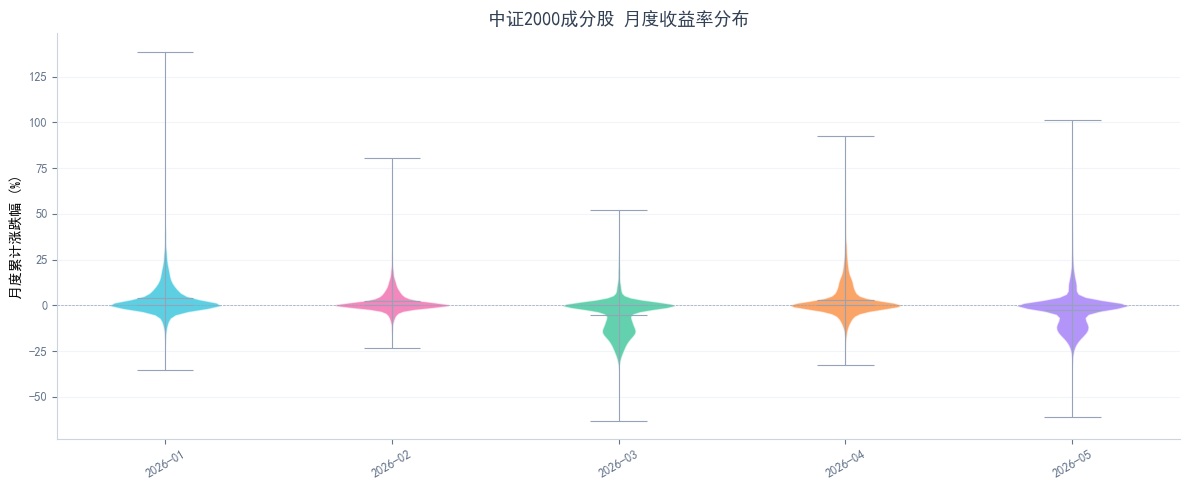

In [5]:
# 图3: 月度收益率分布小提琴图
from dragonflow.viz.charts_matplotlib import plot_monthly_return_violin

fig = plot_monthly_return_violin(daily_df)
plt.show()
plt.close(fig)

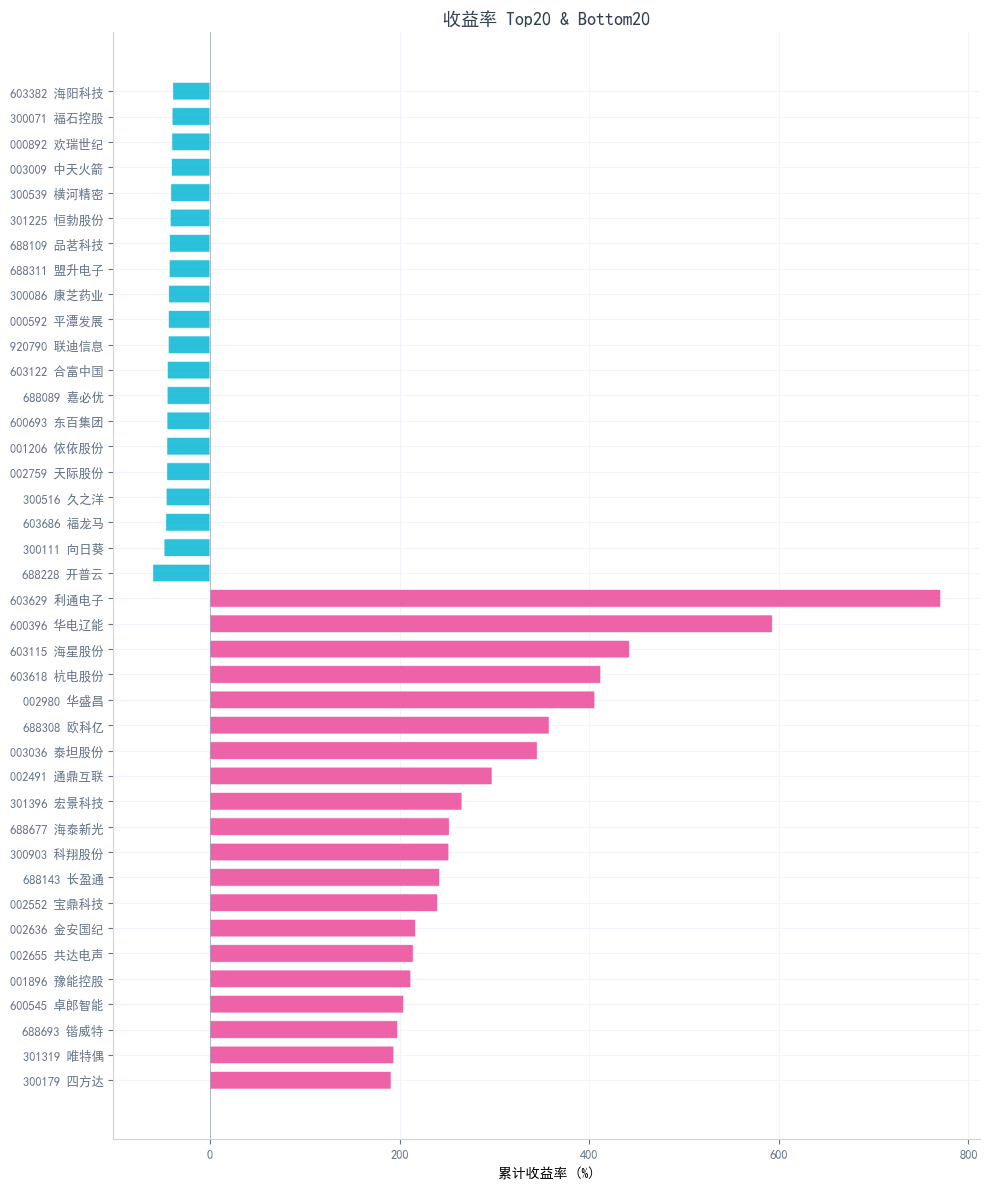

In [6]:
# 图4: 累计收益率 Top20 / Bottom20
from dragonflow.viz.charts_matplotlib import plot_top_bottom_returns

fig = plot_top_bottom_returns(features_df)
plt.show()
plt.close(fig)

In [7]:
# 图5: 全市场日成交额走势
from dragonflow.viz.charts_pyecharts import chart_daily_amount_area

chart_daily_amount_area(daily_df).render_notebook()

---
## Chapter 2: 风险与收益

从波动率、最大回撤、收益分布形态等角度刻画个股风险特征。

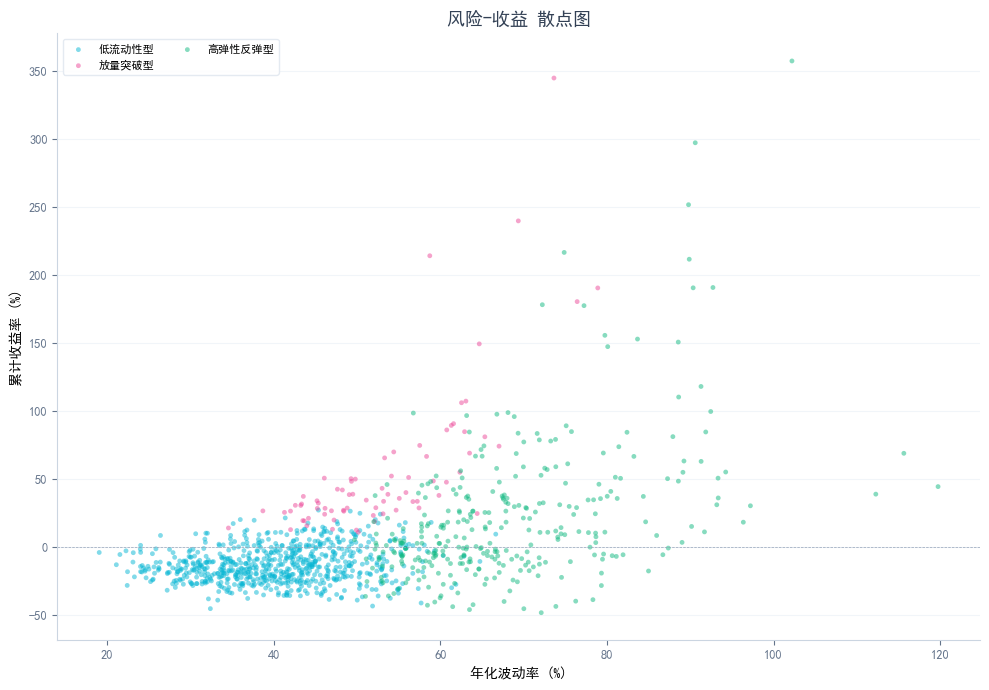

In [8]:
# 图6: 波动率 vs 收益率散点图
from dragonflow.viz.charts_matplotlib import plot_volatility_vs_return

color_col = "cluster_name" if "cluster_name" in features_df.columns else None
fig = plot_volatility_vs_return(features_df, color_col=color_col)
plt.show()
plt.close(fig)

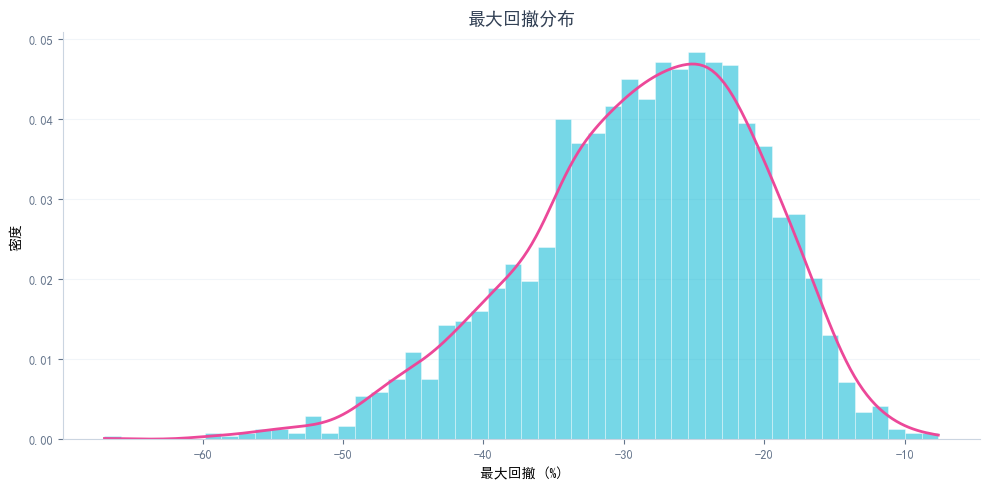

In [9]:
# 图7: 最大回撤分布
from dragonflow.viz.charts_matplotlib import plot_max_drawdown_hist

fig = plot_max_drawdown_hist(features_df)
plt.show()
plt.close(fig)

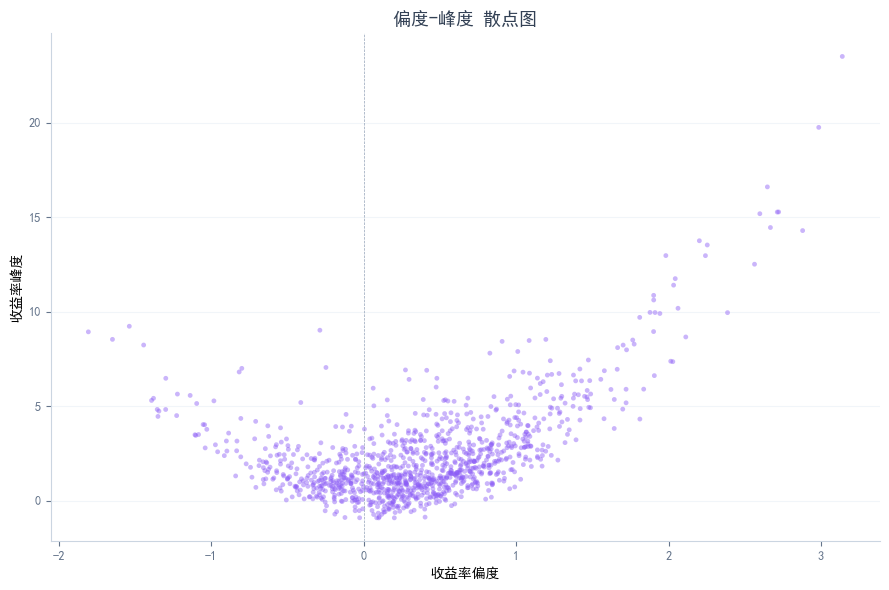

In [10]:
# 图8: 偏度 vs 峰度
from dragonflow.viz.charts_matplotlib import plot_skew_kurtosis

fig = plot_skew_kurtosis(features_df)
plt.show()
plt.close(fig)

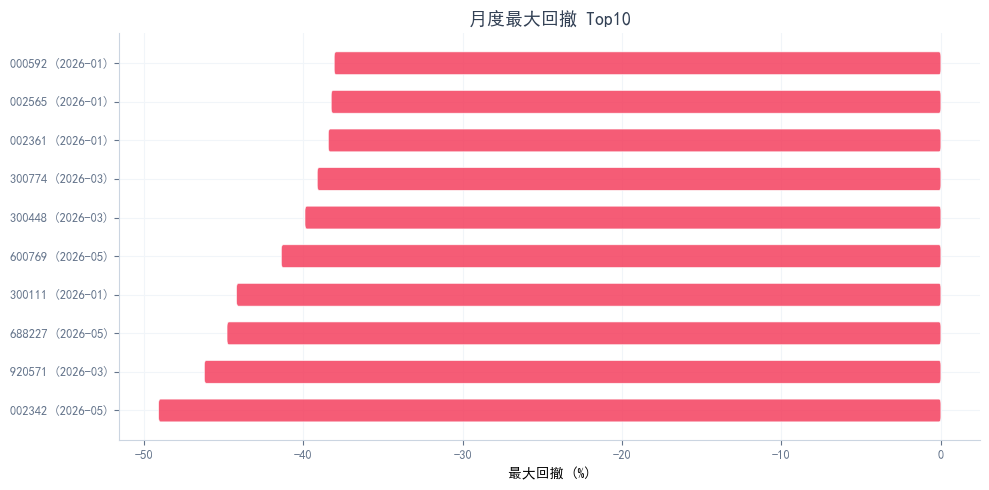

In [11]:
# 图9: 月度最大回撤 Top10
from dragonflow.viz.charts_matplotlib import plot_monthly_drawdown_top

fig = plot_monthly_drawdown_top(daily_df)
plt.show()
plt.close(fig)

---
## Chapter 3: 量价与异动

从换手率、涨跌停、价量关系等维度分析交易行为特征。

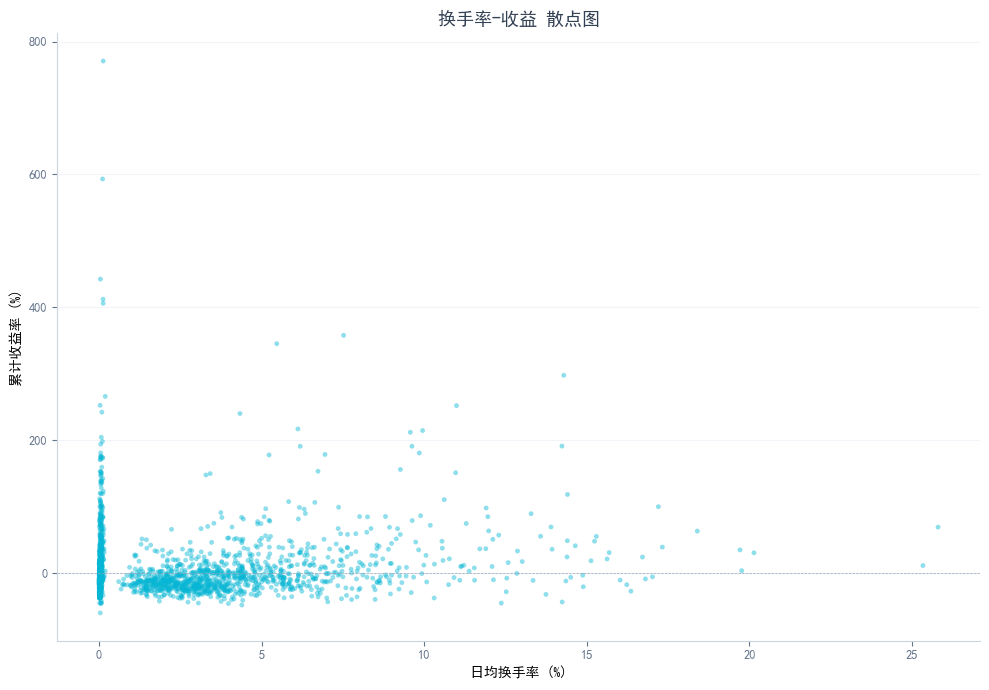

In [12]:
# 图10: 换手率 vs 收益率
from dragonflow.viz.charts_matplotlib import plot_turnover_vs_return

fig = plot_turnover_vs_return(features_df)
plt.show()
plt.close(fig)

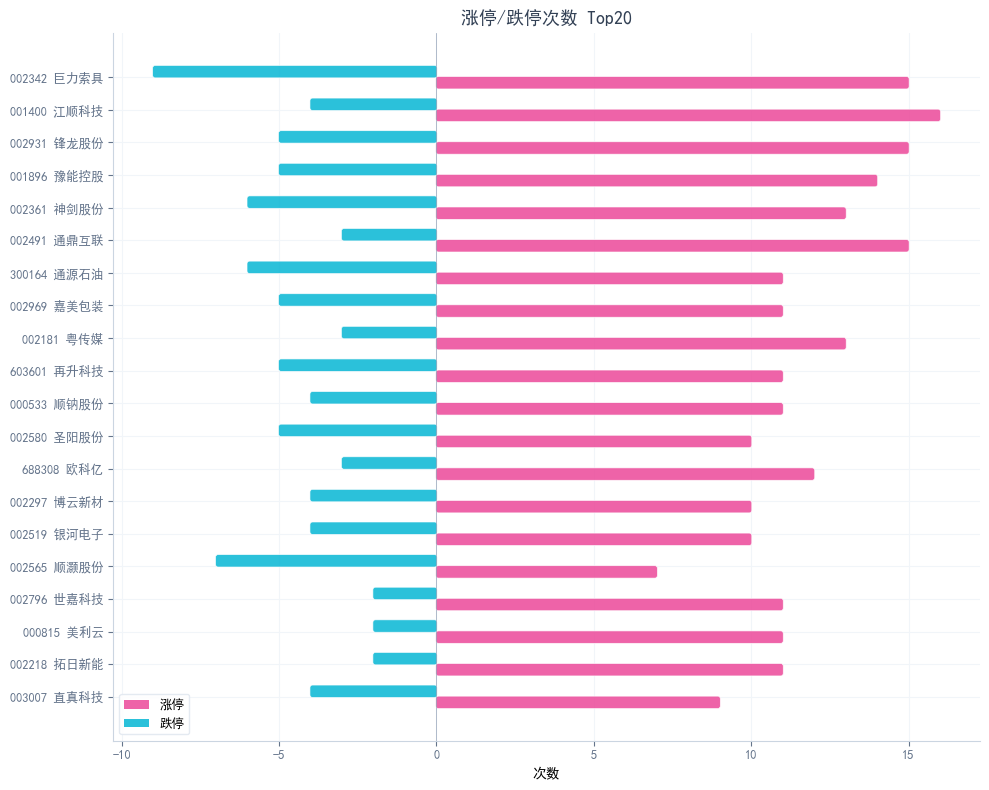

In [13]:
# 图11: 涨停/跌停次数 Top20
from dragonflow.viz.charts_matplotlib import plot_limit_up_down_top

fig = plot_limit_up_down_top(features_df)
plt.show()
plt.close(fig)

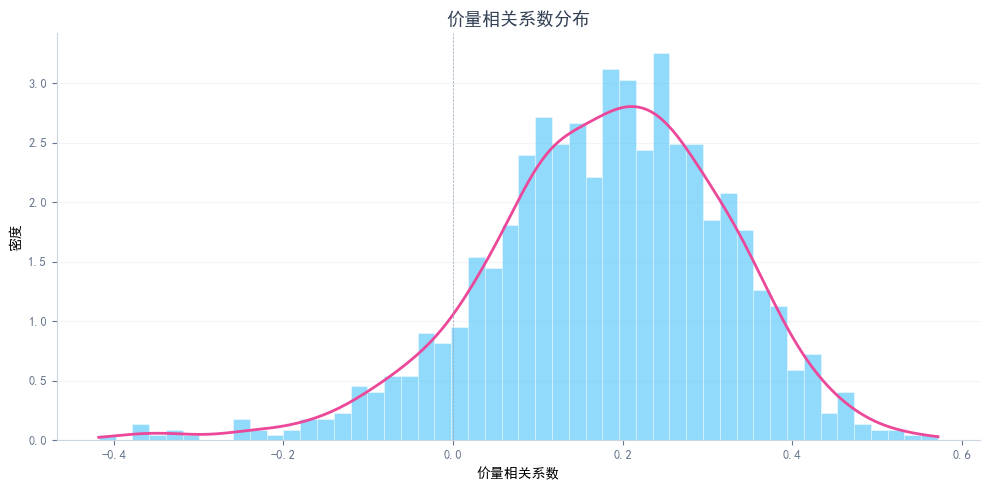

In [14]:
# 图12: 价量相关系数分布
from dragonflow.viz.charts_matplotlib import plot_price_volume_corr_hist

fig = plot_price_volume_corr_hist(features_df)
plt.show()
plt.close(fig)

---
## Chapter 4: 聚类画像

基于 PCA + KMeans 将2000只股票划分为若干类型，用雷达图和箱线图展示每类特征。

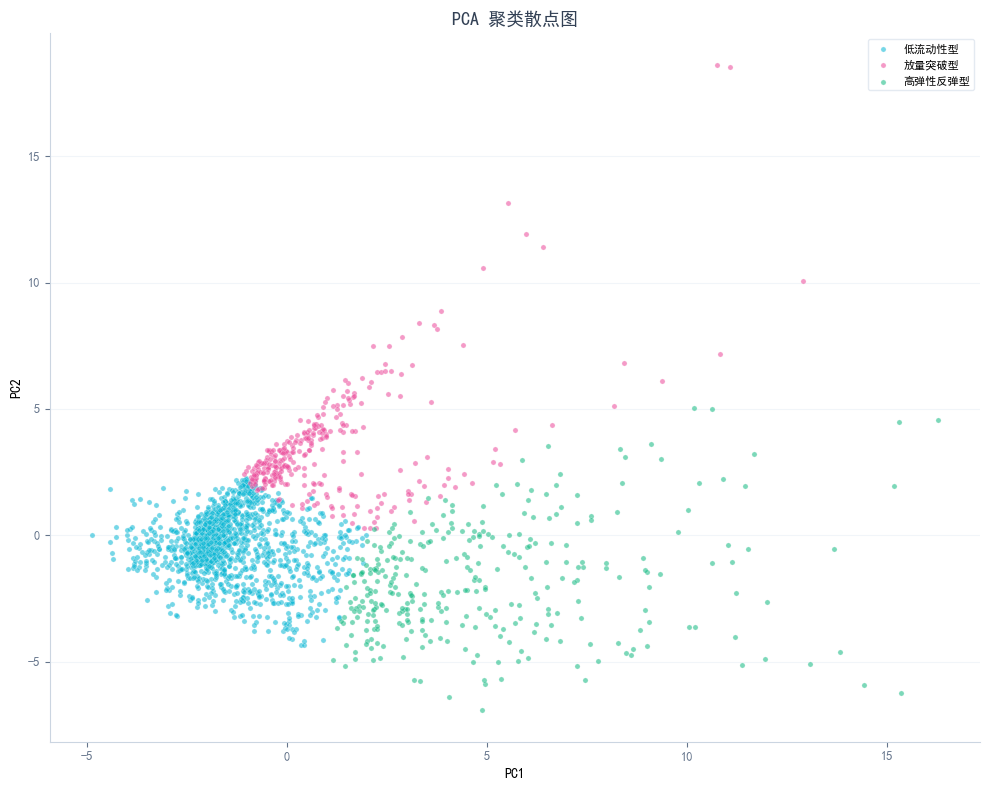

In [15]:
# 图13: PCA 二维聚类散点图
from dragonflow.viz.charts_matplotlib import plot_pca_scatter

if pca_df is not None:
    fig = plot_pca_scatter(pca_df)
    plt.show()
    plt.close(fig)

In [16]:
# 图14: 聚类雷达图
from dragonflow.viz.charts_pyecharts import chart_cluster_radar

if "cluster_name" in features_df.columns:
    chart_cluster_radar(features_df).render_notebook()

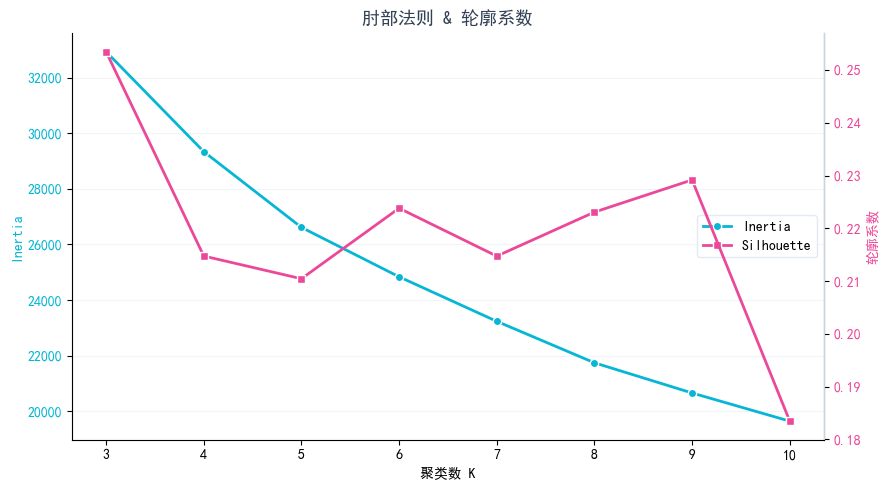

In [17]:
# 图15: 肘部法则 + 轮廓系数
from dragonflow.viz.charts_matplotlib import plot_elbow_silhouette

if k_search_df is not None:
    fig = plot_elbow_silhouette(k_search_df)
    plt.show()
    plt.close(fig)

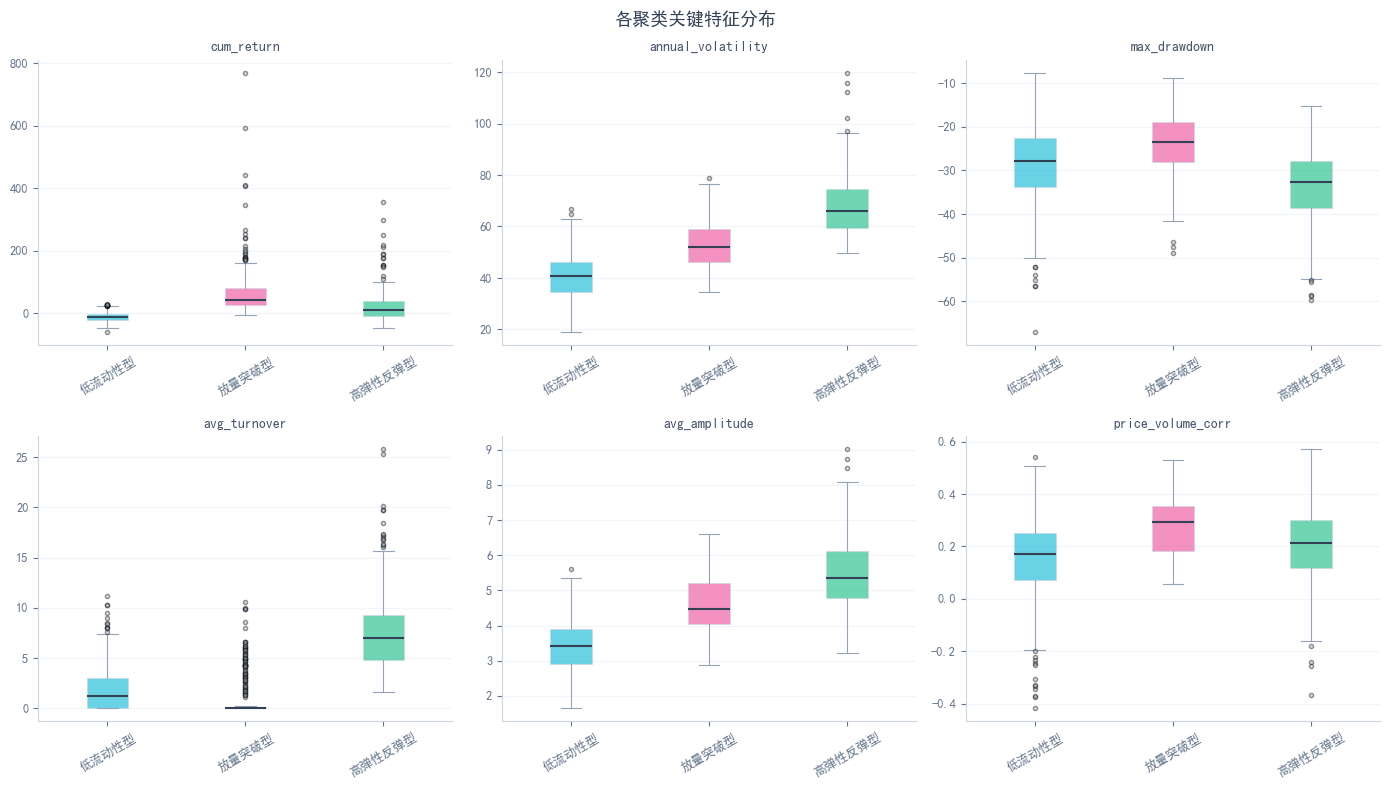

In [18]:
# 图16: 聚类特征分组箱线图
from dragonflow.viz.charts_matplotlib import plot_cluster_boxplot

if "cluster_name" in features_df.columns:
    fig = plot_cluster_boxplot(features_df)
    plt.show()
    plt.close(fig)

---
## Chapter 5: 典型个股

每个聚类选出最具代表性的个股，展示其 K 线走势。

In [19]:
# 选取各聚类代表股
from dragonflow.viz.charts_pyecharts import chart_kline, chart_multi_stock_lines

representatives = {}
if "cluster_name" in features_df.columns:
    for cn, group in features_df.groupby("cluster_name"):
        mean_ret = group["cum_return"].mean()
        closest_idx = (group["cum_return"] - mean_ret).abs().idxmin()
        rep = group.loc[closest_idx]
        code = rep["stock_code"]
        name = rep.get("stock_name", "")
        representatives[cn] = (code, name if isinstance(name, str) else "")
    
    print("各聚类代表股：")
    for cn, (code, name) in representatives.items():
        print(f"  {cn}: {code} {name}")

各聚类代表股：
  低流动性型: 600939 重庆建工
  放量突破型: 688383 新益昌
  高弹性反弹型: 300503 昊志机电


In [20]:
# 图17: 各聚类代表股 K线图
for cn, (code, name) in representatives.items():
    print(f"\n--- {cn}: {code} {name} ---")
    chart_kline(daily_df, code, f"{name} ({cn})").render_notebook()


--- 低流动性型: 600939 重庆建工 ---

--- 放量突破型: 688383 新益昌 ---

--- 高弹性反弹型: 300503 昊志机电 ---


In [21]:
# 图18: 代表股走势叠加对比（归一化）
rep_codes = [code for _, (code, _) in representatives.items()]
rep_names = {code: f"{name}({cn})" for cn, (code, name) in representatives.items()}
chart_multi_stock_lines(daily_df, rep_codes, rep_names).render_notebook()

---
## 聚类结果汇总

In [22]:
if "cluster_name" in features_df.columns:
    display_df = features_df.groupby("cluster_name").agg(
        股票数量=("stock_code", "count"),
        平均收益率=("cum_return", "mean"),
        平均波动率=("annual_volatility", "mean"),
        平均最大回撤=("max_drawdown", "mean"),
        平均换手率=("avg_turnover", "mean"),
        平均振幅=("avg_amplitude", "mean"),
    ).round(2)
    
    print("中证2000成分股 聚类画像汇总")
    print("=" * 60)
    display(display_df)

中证2000成分股 聚类画像汇总


,股票数量,平均收益率,平均波动率,平均最大回撤,平均换手率,平均振幅
cluster_name,,,,,,
低流动性型,1362,-12.50,40.54,-28.62,1.71,3.42
放量突破型,312,67.92,53.21,-24.06,1.09,4.60
高弹性反弹型,326,21.43,68.20,-33.71,7.79,5.53


---

**分析完成。** 以上图表从大盘全景、风险收益、量价异动、聚类画像和典型个股五个角度，系统描述了中证2000成分股在2026年1-5月的市场行为特征。